In [1]:
# Librerie
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

# Caricamento dati
df_auto = pd.read_csv("vehicles_dataset.csv") 

In [2]:
def analizza_statistiche_marca(df: pd.DataFrame) -> pd.DataFrame:
    """
    Raggruppa il DataFrame per marca
    """
    risultato = (
        df.groupby("manufacturer")
          .agg(
              modelli_unici=("model", "nunique"),
              count_modelli=("model", "count"),
              prezzo_medio=("price", "mean")  
          )
          .reset_index()
          .sort_values(by="count_modelli", ascending=False)
          .round({"prezzo_medio": 2}) 
    )
    return risultato

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def crea_grafico_modelli_per_marca(risultato: pd.DataFrame, output_path: str = "grafici/modelli_per_marca.png"):
    """
    Genera un istogramma orizzontale comparativo tra modelli unici e totali per ogni marca.
    """
    # 1. Preparazione dati e totali per la legenda
    totale_unici = risultato["modelli_unici"].sum()
    totale_complessivo = risultato["count_modelli"].sum()
    
    # Ora usiamo 'y' invece di 'x' per le posizioni
    y = np.arange(len(risultato["manufacturer"]))
    height = 0.4 # Sostituiamo 'width' con 'height'

    # Potresti voler aumentare leggermente l'altezza della figura se ci sono molte marche
    plt.figure(figsize=(13, 10))

    # 2. Barre Modelli Unici (orizzontali)
    plt.barh(
        y - height / 2,
        risultato["modelli_unici"],
        height=height,
        color="#1f77b4",
        label=f"Modelli unici ({totale_unici:})",
        zorder=3,
    )

    # 3. Barre Totale Modelli (orizzontali)
    bars_totali = plt.barh(
        y + height / 2,
        risultato["count_modelli"],
        height=height,
        color="#ff7f0e",
        label=f"Totale modelli ({totale_complessivo:})",
        zorder=3,
    )

    # 4. Aggiunta etichette alla fine delle colonne del totale
    # Il padding ora spinge il testo verso destra
    plt.bar_label(bars_totali, padding=3, fmt='%d', fontsize=11)

    # 5. Configurazione Assi e Scala
    plt.yticks(y, risultato["manufacturer"]) 
    plt.ylabel("Marche", fontsize=14)
    plt.xlabel("Log(Conteggio)") 
    plt.xscale("log")            # Si applica sull'asse X la scala logaritmica ora
    plt.title("Distribuzione Modelli per Marca", fontsize=22)#, fontweight='bold')

    # 6. Griglia e Legenda
    plt.grid(True, which="both", axis="x", linestyle="--", alpha=0.15, zorder=1)
    plt.legend(fontsize=18, loc='upper right') # Spostata in basso a destra per non coprire le barre in alto
    
    plt.tight_layout()

    # 7. Salvataggio e Visualizzazione
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Grafico salvato con successo in: {output_path}")

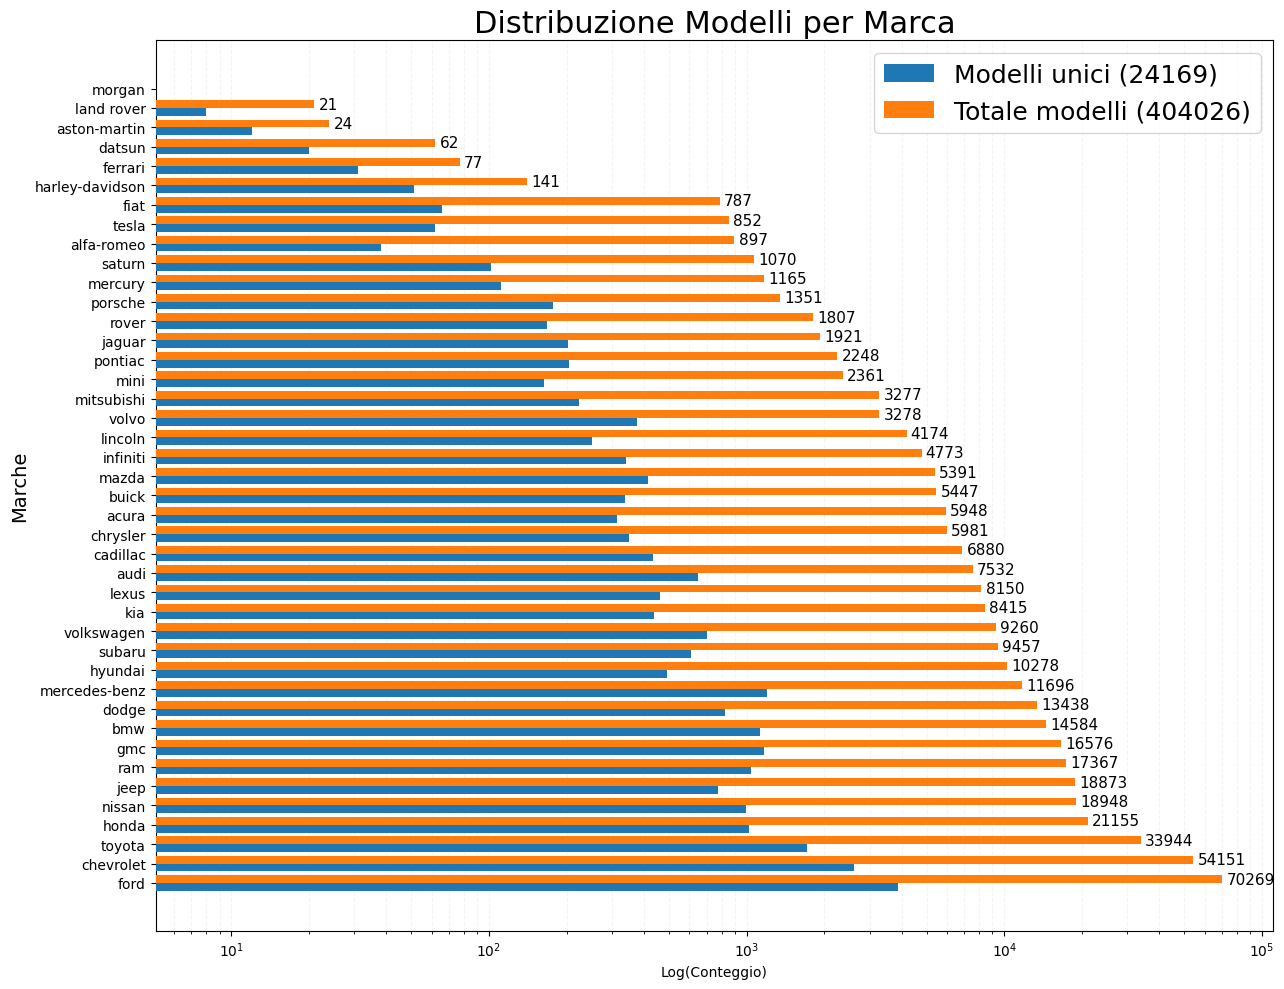

Grafico salvato con successo in: grafici/modelli_per_marca.png


In [3]:
# Applicazione della funzione per il raggruppamento per marca
df_analisi = analizza_statistiche_marca(df_auto)

# Creazione del grafico Modelli per marca
crea_grafico_modelli_per_marca(df_analisi, "grafici/modelli_per_marca.png")

In [4]:
def calcola_prezzi_medi_marca(df: pd.DataFrame) -> pd.DataFrame:
    """
    Raggruppa il DataFrame per marca, calcola il prezzo medio 
    e ordina i risultati in modo decrescente.
    """
    df_prezzi_marche = (
        df.groupby("manufacturer")["price"]
        .mean()
        .reset_index()
        .sort_values(by="price", ascending=False)
        .round(2)  # Arrotondiamo a due decimali per i prezzi
    )
    
    return df_prezzi_marche

def crea_grafico_prezzo_medio(df_prezzi_marche: pd.DataFrame, output_path: str = "grafici/prezzo_medio_completo.png"):
    """
    Genera e salva un grafico a barre orizzontali che mostra la classifica 
    del prezzo medio per marca, con le etichette numeriche per OGNI barra.
    """
    palette_personalizzata = sns.color_palette("blend:#1f77b4,#ff7f0e", n_colors=len(df_prezzi_marche))

    plt.figure(figsize=(20, 10))

    ax = sns.barplot(
        x="price", 
        y="manufacturer", 
        data=df_prezzi_marche, 
        palette=palette_personalizzata,
        hue="manufacturer",
        legend=False
    )

    # ==========================================
    # CORREZIONE: Cicliamo su TUTTI i container 
    # creati dal parametro "hue" di Seaborn
    # ==========================================
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.2f',   
            padding=5,      
            fontsize=10,
            color="#333333" 
        )

    # Estendiamo l'asse X per non tagliare le etichette
    #valore_massimo = df_prezzi_marche["price"].max()
    #ax.set_xlim(0, valore_massimo * 1.10)

    # Personalizzazione titoli e assi
    plt.title("Classifica del Prezzo Medio delle Auto Usate per Marca", fontsize=16, pad=16)
    plt.xlabel("Log(Prezzo Medio) $", fontsize=14)
    plt.xscale('log')
    plt.ylabel("Marche", fontsize=14)

    # Griglia spessa, scura e continua
    plt.grid(axis='x', color='red', linewidth=1.5, linestyle='-')

    # Ottimizzazione margini
    plt.tight_layout()
    
    # Salvataggio e visualizzazione
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Grafico salvato con successo in: {output_path}")


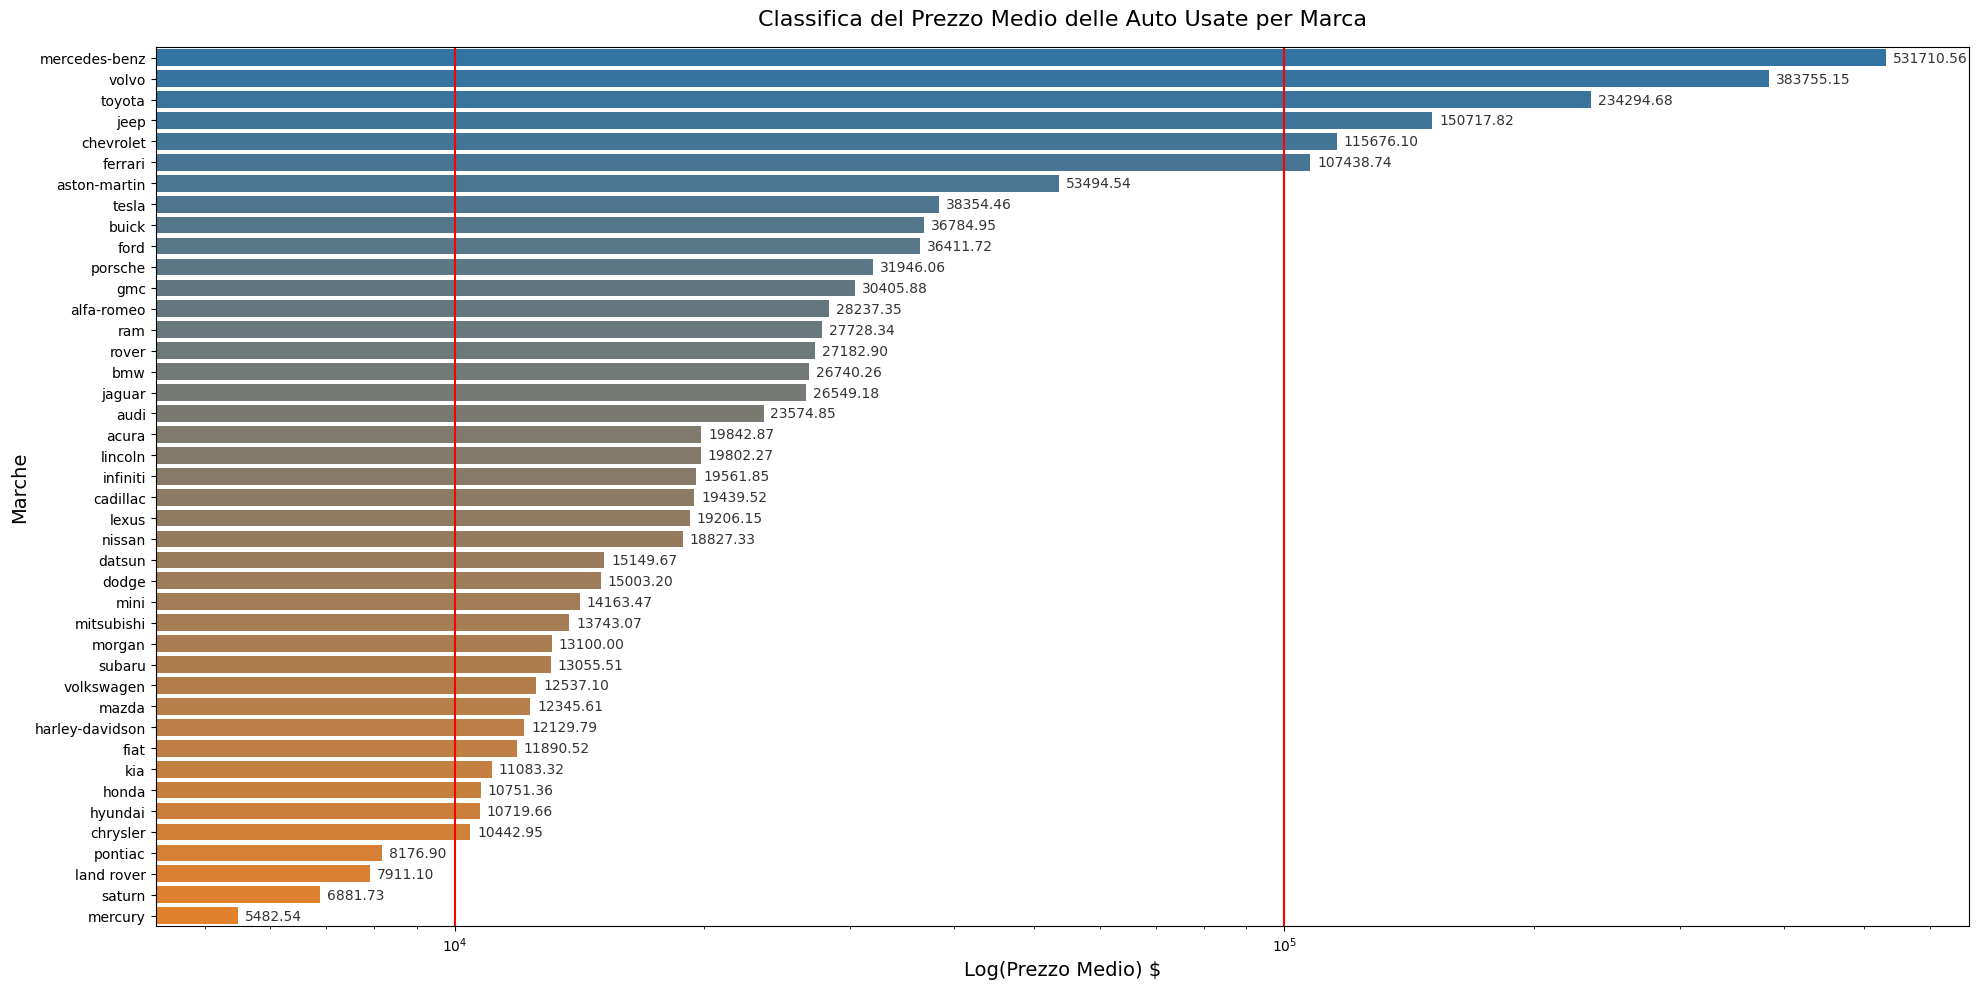

Grafico salvato con successo in: grafici/prezzo_medio_completo.png


In [5]:
# 1. Calcoli i dati passando il tuo DataFrame originale
df_risultati_prezzi = calcola_prezzi_medi_marca(df_auto)

# 2. Passi l'output della prima funzione direttamente alla seconda
crea_grafico_prezzo_medio(df_risultati_prezzi, "grafici/prezzo_medio_completo.png")

In [6]:
# =========================================================================
# PULIZIA OUTLIERS PER OGNI MARCA COL METODO IQR (SU TUTTO IL DATAFRAME)
# =========================================================================
# Calcoliamo i limiti di prezzo specifici per ogni brand direttamente su df,
# evitando che i prezzi folli di una marca sballino i dati delle altre.

lista_pezzi_puliti = []
tutte_le_marche = df_auto['manufacturer'].unique()

print(f"Numero di righe totali del DataFrame PRIMA della pulizia: {df_auto.shape[0]}")

# Cicliamo su ogni singola marca presente nel dataset
for marca in tutte_le_marche:
    
    # Isoliamo temporaneamente le auto della marca corrente
    dati_marca = df_auto[df_auto['manufacturer'] == marca]
    
    # Calcoliamo l'IQR solo se abbiamo un numero minimo di dati per renderlo affidabile
    if dati_marca.shape[0] > 10:
        q1 = dati_marca['price'].quantile(0.25)
        q3 = dati_marca['price'].quantile(0.75)
        iqr = q3 - q1
        
        # Definiamo i confini personalizzati per questo brand
        limite_inferiore = q1 - 1.5 * iqr
        limite_superiore = q3 + 1.5 * iqr
        
        # Di sicurezza: i prezzi non possono essere negativi o stracciati (es. 0$ o 1$)
        if limite_inferiore < 500:
            limite_inferiore = 500
    else:
        # Se la marca ha pochissimi annunci, usiamo un filtro standard di sicurezza
        limite_inferiore = 500
        limite_superiore = 100000

    # Filtriamo le auto della marca corrente che rientrano nei limiti accettabili
    auto_pulite_marca = dati_marca[(dati_marca['price'] >= limite_inferiore) & 
                                   (dati_marca['price'] <= limite_superiore)]
    
    # Salviamo il blocco pulito nella nostra lista
    lista_pezzi_puliti.append(auto_pulite_marca)

# =========================================================================
# RICOSTRUZIONE DEL DATAFRAME AGGIORNATO
# =========================================================================
# Ricompattiamo tutti i pezzi puliti in un unico DataFrame sovrascrivendo df
df = pd.concat(lista_pezzi_puliti, axis=0).reset_index(drop=True)

print("=========================================================================")
print("PULIZIA COMPLETA DEGLI OUTLIERS EFFETTUATA SU 'df'!")
print(f"-> Numero di righe totali del DataFrame DOPO la pulizia: {df.shape[0]}")
print("=========================================================================")
e = df_auto.shape[0] - df.shape[0]
print(f"Record eliminati {e}")
print("=========================================================================")

Numero di righe totali del DataFrame PRIMA della pulizia: 426880
PULIZIA COMPLETA DEGLI OUTLIERS EFFETTUATA SU 'df'!
-> Numero di righe totali del DataFrame DOPO la pulizia: 362358
Record eliminati 64522


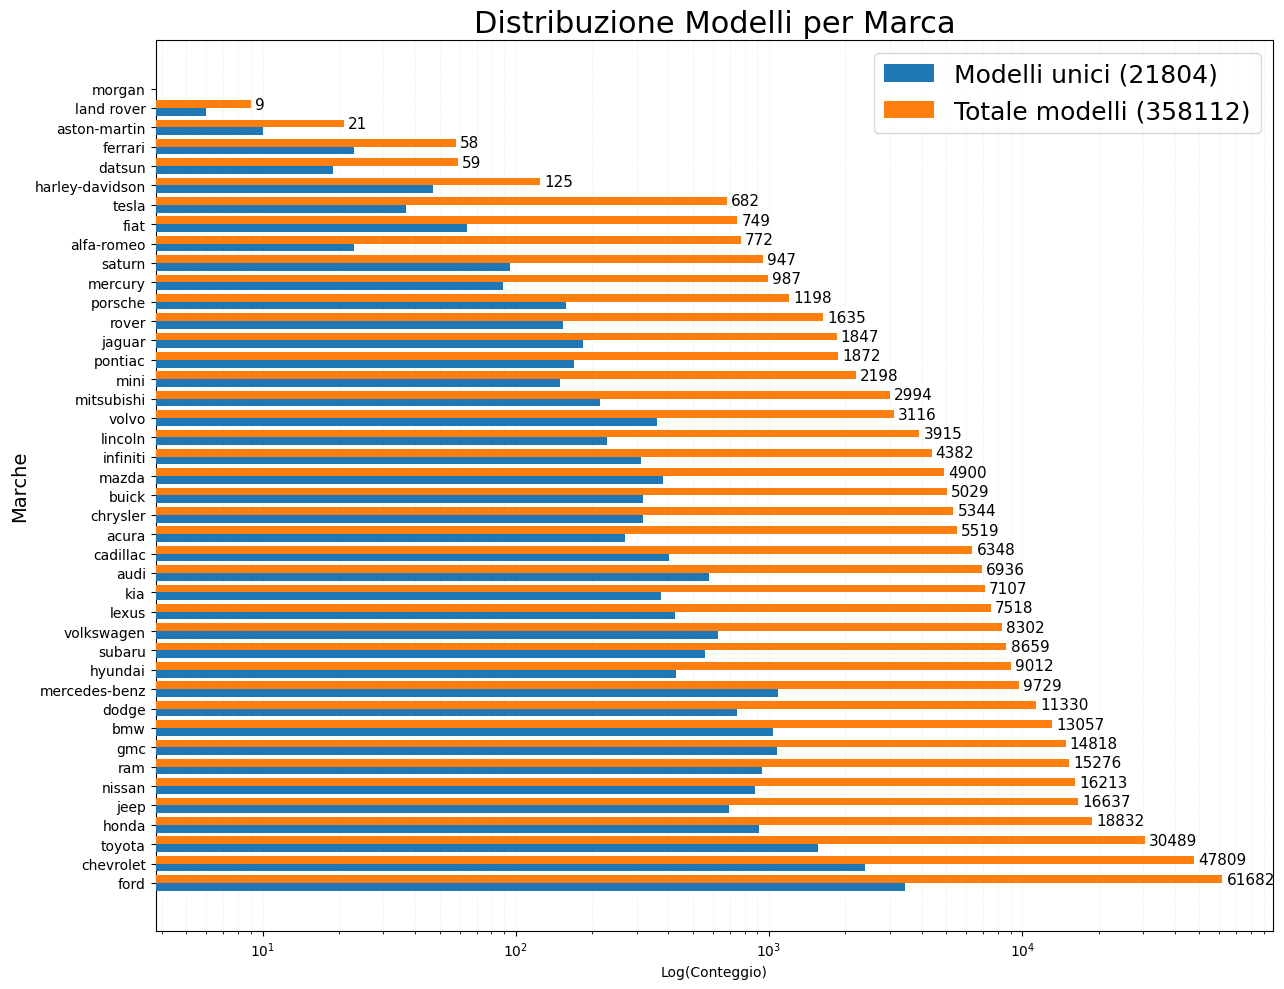

Grafico salvato con successo in: grafici/modelli_per_marca_aftercut.png


In [7]:
# Applicazione della funzione per il raggruppamento per marca
df_analisi = analizza_statistiche_marca(df)

# Creazione del grafico Modelli per marca
crea_grafico_modelli_per_marca(df_analisi, "grafici/modelli_per_marca_aftercut.png")

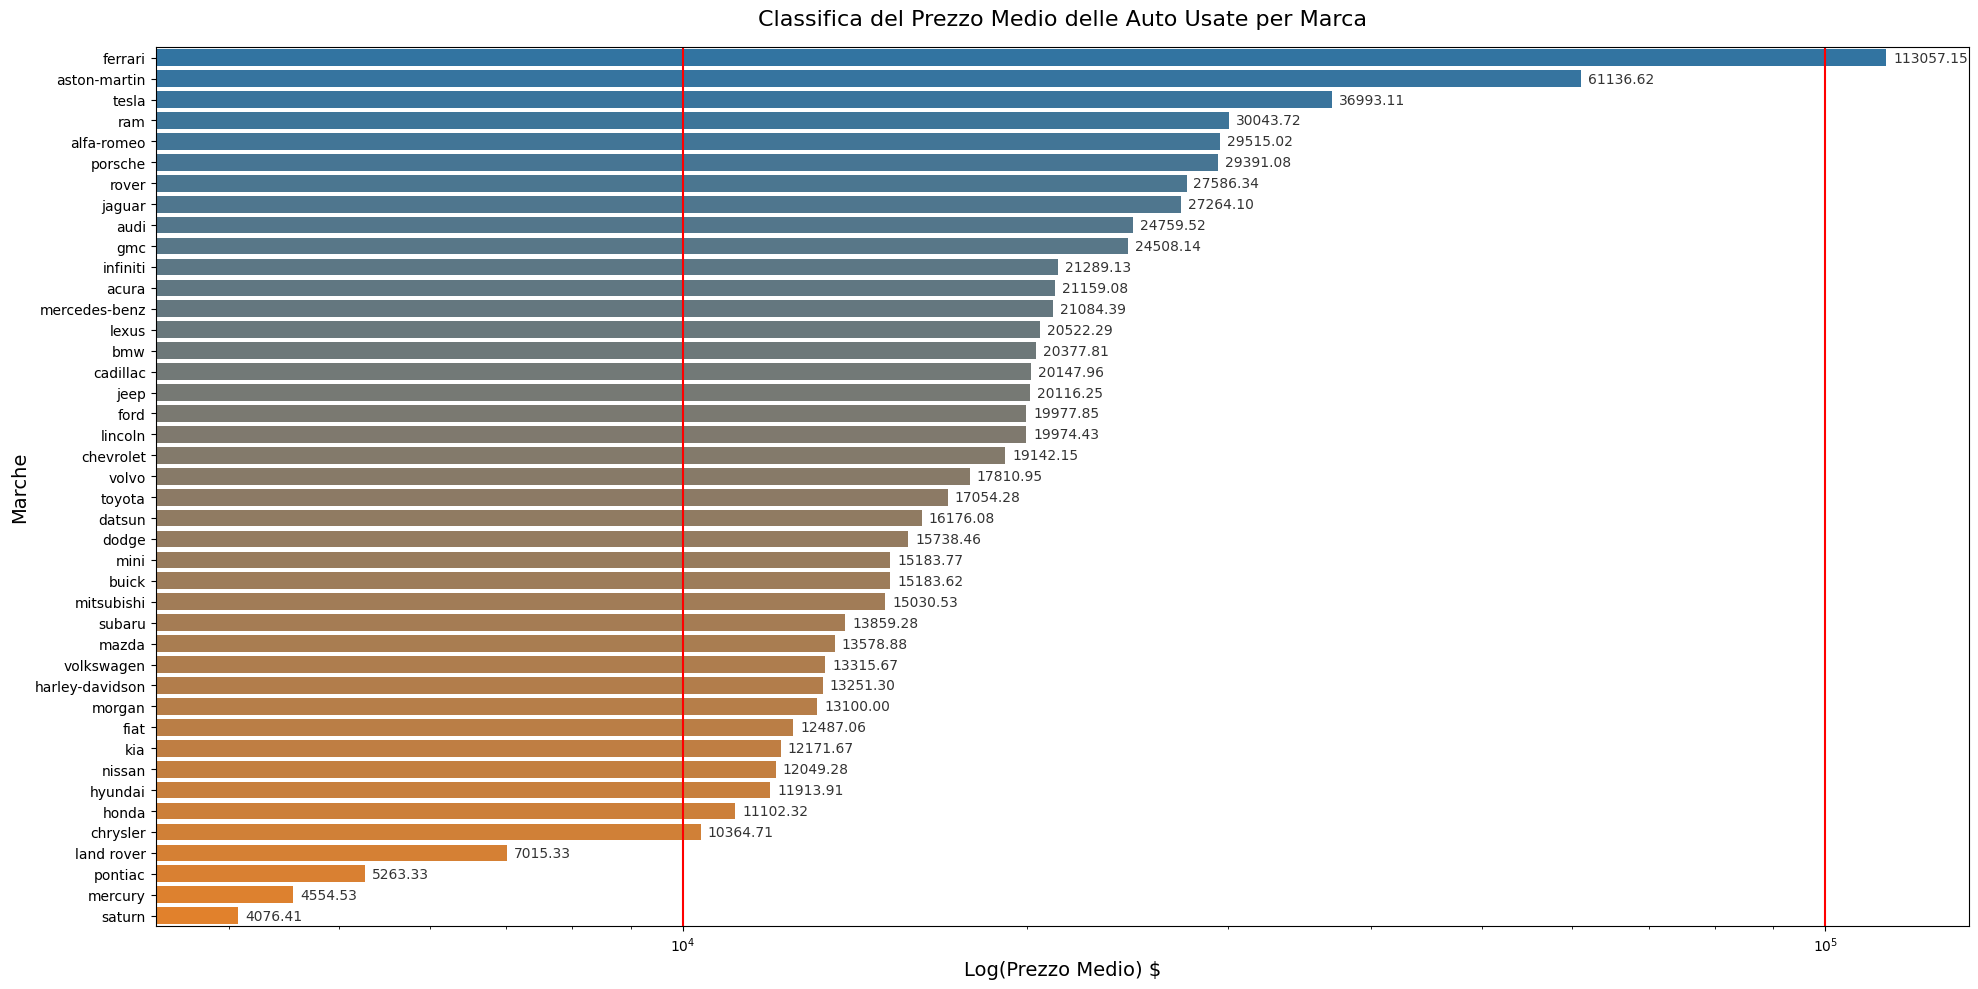

Grafico salvato con successo in: grafici/prezzo_medio_aftercut.png


In [8]:
# 1. Calcoli i dati passando il tuo DataFrame originale
df_risultati_prezzi = calcola_prezzi_medi_marca(df)

# 2. Passi l'output della prima funzione direttamente alla seconda
crea_grafico_prezzo_medio(df_risultati_prezzi, "grafici/prezzo_medio_aftercut.png")

In [9]:
# =========================================================================
# RIMOZIONE COMPLETA DEI BRAND OUTLIER (SUPERCAR E MARCHE TROPPO ECONOMICHE)
# =========================================================================
totale_iniziale = df.shape[0]
print("=========================================================================")
print(f"Numero di auto all'inizio della pulizia: {totale_iniziale}")
print("=========================================================================\n")

# Lista di marche da escludere
marche_da_escludere = ['ferrari', 'aston-martin', 'saturn', 'mercury', 'pontiac', 'land rover', 'morgan', 'datsun', 'harley-davidson']

# Contiamo e stampiamo quante auto stiamo per eliminare per ogni marca
print("Dettaglio auto da eliminare per marca:")
conteggi_attuali = df['manufacturer'].value_counts()

for marca in marche_da_escludere:
    # Usiamo .get(marca, 0) in modo che se una marca ha 0 auto, restituisca 0 senza dare errore
    da_eliminare = conteggi_attuali.get(marca, 0) 
    print(f" - {marca.capitalize():<15}: rimosse {da_eliminare} auto")

# Applichiamo il filtro combinato (teniamo solo ciò che NON è in 'marche_da_escludere')
df = df[~df['manufacturer'].isin(marche_da_escludere)].reset_index(drop=True)

totale_finale = df.shape[0]

print("\n=========================================================================")
print("RIMOZIONE COMPLETATA CON SUCCESSO!")
print(f"-> Totale auto eliminate in questo passaggio: {totale_iniziale - totale_finale}")
print(f"-> Numero di auto finali rimaste nel DataFrame: {totale_finale}")
print("=========================================================================")

Numero di auto all'inizio della pulizia: 362358

Dettaglio auto da eliminare per marca:
 - Ferrari        : rimosse 75 auto
 - Aston-martin   : rimosse 21 auto
 - Saturn         : rimosse 965 auto
 - Mercury        : rimosse 995 auto
 - Pontiac        : rimosse 1908 auto
 - Land rover     : rimosse 9 auto
 - Morgan         : rimosse 3 auto
 - Datsun         : rimosse 59 auto
 - Harley-davidson: rimosse 134 auto

RIMOZIONE COMPLETATA CON SUCCESSO!
-> Totale auto eliminate in questo passaggio: 4169
-> Numero di auto finali rimaste nel DataFrame: 358189


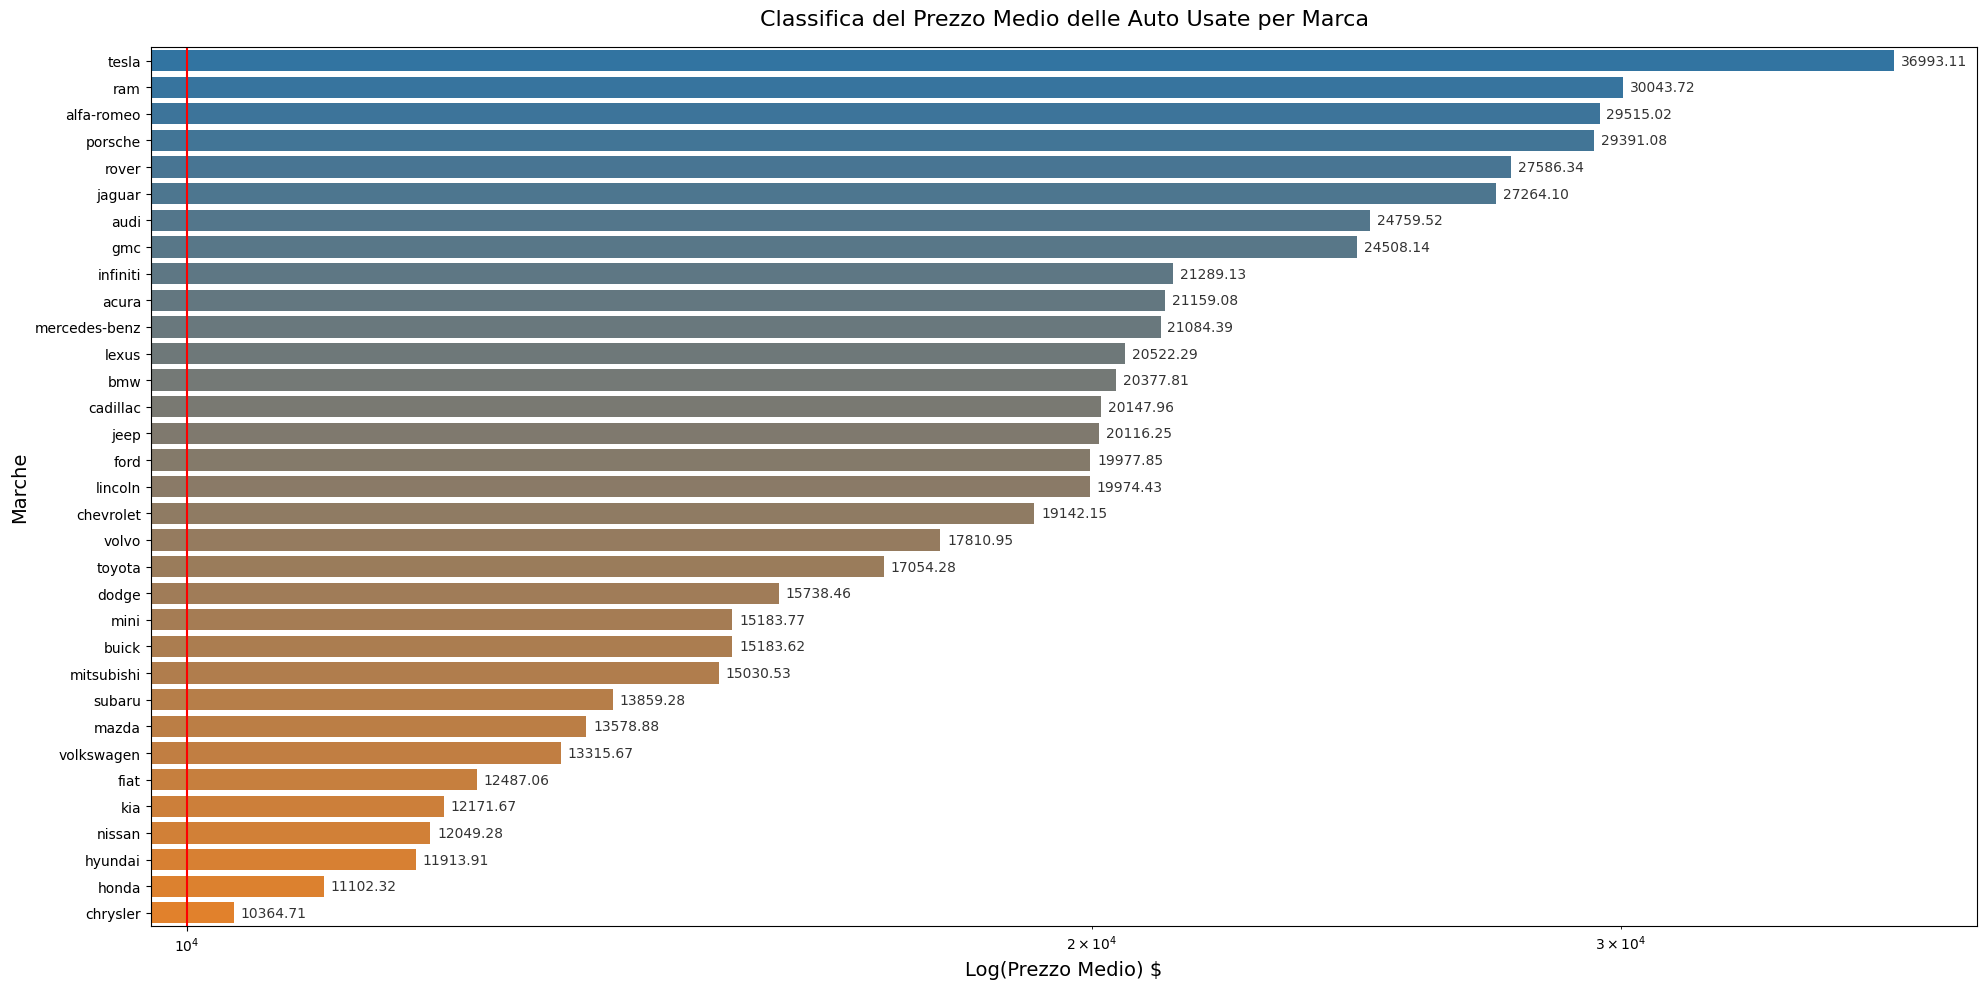

Grafico salvato con successo in: grafici/prezzo_medio_final.png


In [10]:
# 1. Calcoli i dati passando il tuo DataFrame originale
df_risultati_prezzi = calcola_prezzi_medi_marca(df)

# 2. Passi l'output della prima funzione direttamente alla seconda
crea_grafico_prezzo_medio(df_risultati_prezzi, "grafici/prezzo_medio_final.png")

In [11]:
# Visualizzazione rapida dei nomi delle colonne del loro tipo e del numero di valori mancanti
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358189 entries, 0 to 358188
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         358189 non-null  int64  
 1   year          358185 non-null  float64
 2   manufacturer  358189 non-null  object 
 3   model         354034 non-null  object 
 4   condition     222889 non-null  object 
 5   cylinders     212090 non-null  object 
 6   fuel          356078 non-null  object 
 7   odometer      356247 non-null  float64
 8   title_status  351935 non-null  object 
 9   transmission  356543 non-null  object 
 10  drive         250088 non-null  object 
 11  size          100516 non-null  object 
 12  type          282839 non-null  object 
 13  paint_color   254641 non-null  object 
 14  state         358189 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 41.0+ MB


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Distribuzione degli anni 
def crea_grafico_distribuzione_anni(df: pd.DataFrame, output_path: str = "grafici/distribuzione_anni.png"):
    """
    Genera e salva un istogramma che mostra la distribuzione 
    degli anni di immatricolazione delle auto.
    """
    plt.figure(figsize=(8, 6))
    
    # Rimuoviamo eventuali valori nulli nella colonna anno per evitare errori
    df_plot = df.dropna(subset=['year'])
    
    # Generiamo l'istogramma e lo salviamo nella variabile 'ax'
    ax = sns.histplot(
        data=df_plot, 
        x="year", 
        discrete=True, 
        color="#1D4E89",          # NUOVO BLU: Moderno, pulito e vivace
        kde=True,
        line_kws={'linewidth': 2} # Impostiamo solo lo spessore qui
    )
    
    # TRUCCO INFALLIBILE: 
    # ax.lines[0] rappresenta la prima (e unica) linea disegnata sul grafico (la KDE)
    # Le forziamo il colore arancione
    ax.lines[0].set_color('#ff7f0e')
    
    plt.title("Distribuzione dell'Anno di Immatricolazione", fontsize=16, pad=15)
    plt.xlabel("Anno", fontsize=12)
    plt.ylabel("Numero di Annunci", fontsize=12)
    
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Ottimizziamo l'asse X per evitare che le etichette si accavallino.
    # Stampiamo un anno (tick) ogni 5 anni
    anno_min = int(df_plot["year"].min())
    anno_max = int(df_plot["year"].max())
    plt.xticks(range(anno_min, anno_max + 1, 5), rotation=45)
    plt.xlim(1985, 2023)

    plt.tight_layout()
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Grafico salvato con successo in: {output_path}")

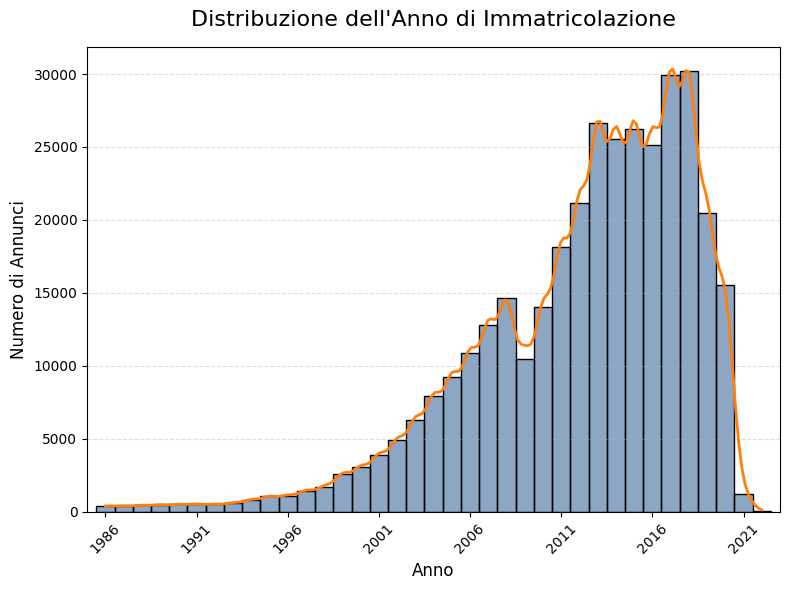

Grafico salvato con successo in: grafici/distribuzione_anni.png


In [25]:
crea_grafico_distribuzione_anni(df, "grafici/distribuzione_anni.png")

In [26]:
# Contiamo ed eliminiamo le auto più vecchie del 1990

# =========================================================================
# RIMOZIONE DELLE AUTO STORICHE O TROPPO VECCHIE (PRE-1990)
# =========================================================================
totale_prima_anno = df.shape[0]

# Contiamo quante auto sono state immatricolate prima del 1990
# Usiamo < 1990 (quindi dal 1989 in giù)
auto_da_rimuovere = df[df['year'] < 1986].shape[0]

# Filtriamo il DataFrame mantenendo SOLO le auto dal 1990 in poi
df = df[df['year'] >= 1986].reset_index(drop=True)

totale_dopo_anno = df.shape[0]

print("=========================================================================")
print(f"Numero di auto all'inizio di questo step: {totale_prima_anno}")
print(f"Auto storiche (pre-1990) individuate e rimosse: {auto_da_rimuovere}")
print("-------------------------------------------------------------------------")
print("RIMOZIONE AUTO VECCHIE COMPLETATA!")
print(f"-> Numero di auto finali rimaste nel DataFrame: {totale_dopo_anno}")
print("=========================================================================")

Numero di auto all'inizio di questo step: 351045
Auto storiche (pre-1990) individuate e rimosse: 0
-------------------------------------------------------------------------
RIMOZIONE AUTO VECCHIE COMPLETATA!
-> Numero di auto finali rimaste nel DataFrame: 351045


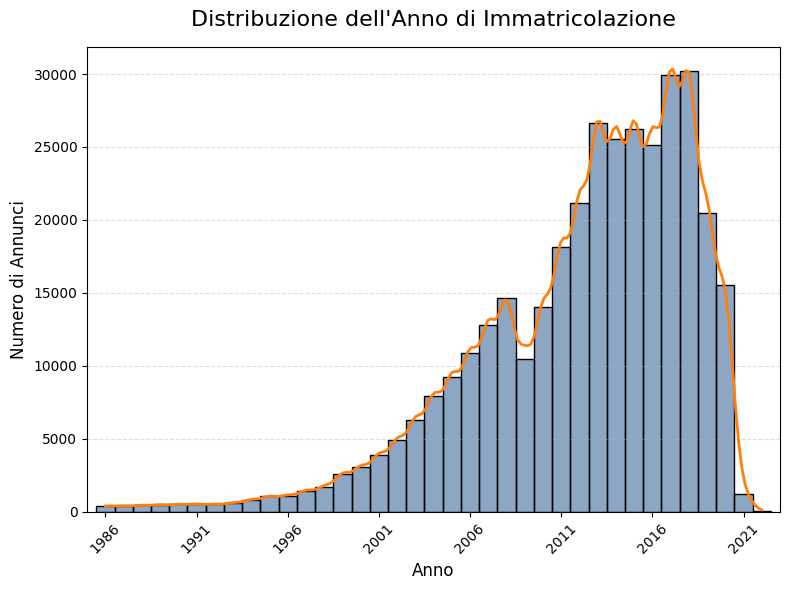

Grafico salvato con successo in: grafici/distribuzione_anni_aftercut.png


In [27]:
crea_grafico_distribuzione_anni(df, "grafici/distribuzione_anni_aftercut.png")

/var/folders/vp/w9hfvh7j2dggvm8tlpf5831m0000gn/T/ipykernel_10444/3718663391.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etichette_attuali, rotation=0)


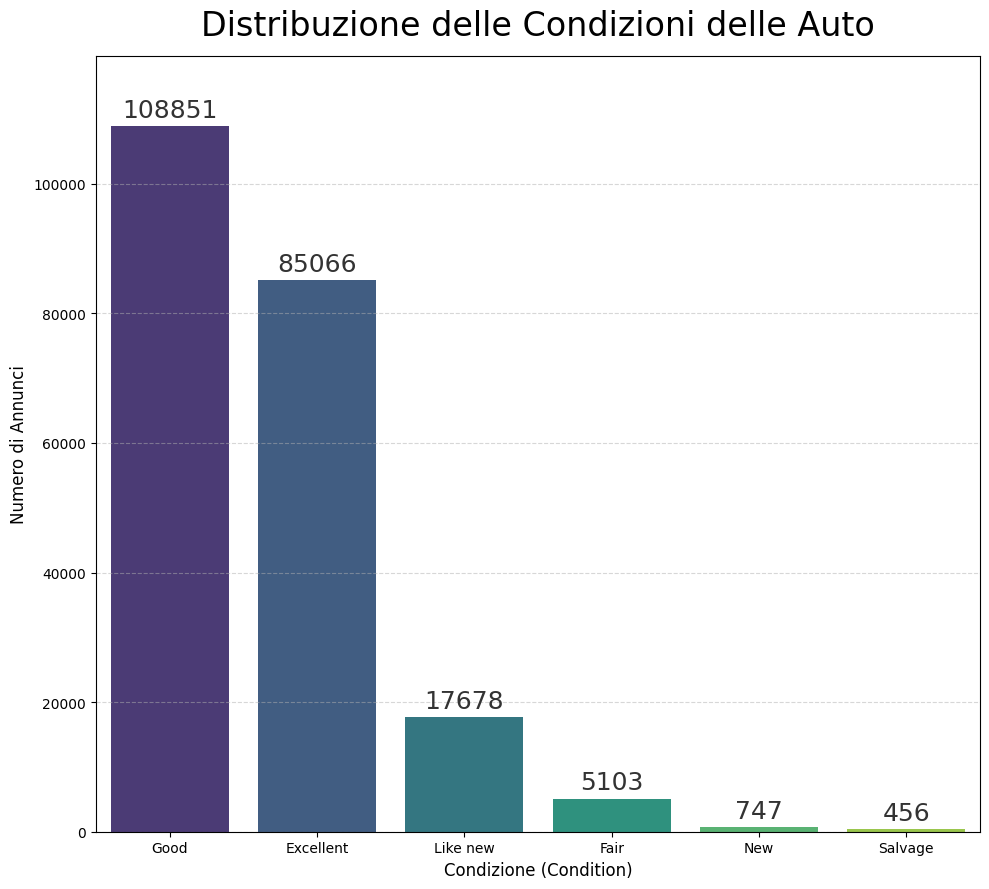

Grafico salvato con successo in: grafici/condizioni_auto.png


In [37]:
def crea_grafico_condizioni(df: pd.DataFrame, output_path: str = "grafici/condizioni_auto.png"):
    """
    Genera e salva un grafico a barre che mostra la frequenza 
    di ogni categoria nella colonna 'condition'.
    """
    # Rimuoviamo eventuali valori nulli per non avere una colonna "NaN" nel grafico
    df_plot = df.dropna(subset=['condition'])
    
    # Calcoliamo i conteggi e li ordiniamo dal maggiore al minore
    conteggi_condizioni = df_plot['condition'].value_counts().reset_index()
    # Rinominiamo le colonne per chiarezza
    conteggi_condizioni.columns = ['condition', 'count']
    
    plt.figure(figsize=(10, 9))
    
    # Creiamo il grafico a barre verticali
    ax = sns.barplot(
        data=conteggi_condizioni,
        x='condition',
        y='count',
        palette="viridis",
        hue='condition',
        legend=False
    )
    
    # Aggiungiamo i valori esatti in cima a ogni barra
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%d',       # Numero intero
            padding=3,      # Spazio tra la barra e il numero
            fontsize=18,
            color="#333333"
        )
    
    # Per non tagliare le etichette della barra più alta, alziamo il limite dell'asse Y del 10%
    valore_massimo = conteggi_condizioni['count'].max()
    ax.set_ylim(0, valore_massimo * 1.10)
    
    # Personalizzazione titoli e assi
    plt.title("Distribuzione delle Condizioni delle Auto", fontsize=24, pad=15)
    plt.xlabel("Condizione (Condition)", fontsize=12)
    plt.ylabel("Numero di Annunci", fontsize=12)
    
    # Griglia orizzontale per leggere meglio i volumi
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Capitalizziamo i nomi sull'asse X (es. 'excellent' -> 'Excellent') per renderli più belli
    etichette_attuali = [label.get_text().capitalize() for label in ax.get_xticklabels()]
    ax.set_xticklabels(etichette_attuali, rotation=0) 
    # Se le etichette dovessero sovrapporsi, puoi cambiare rotation=0 in rotation=45
    
    plt.tight_layout()
    
    # Salvataggio e visualizzazione
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Grafico salvato con successo in: {output_path}")

# =========================================================================
# ESEMPIO DI UTILIZZO
# =========================================================================
crea_grafico_condizioni(df)

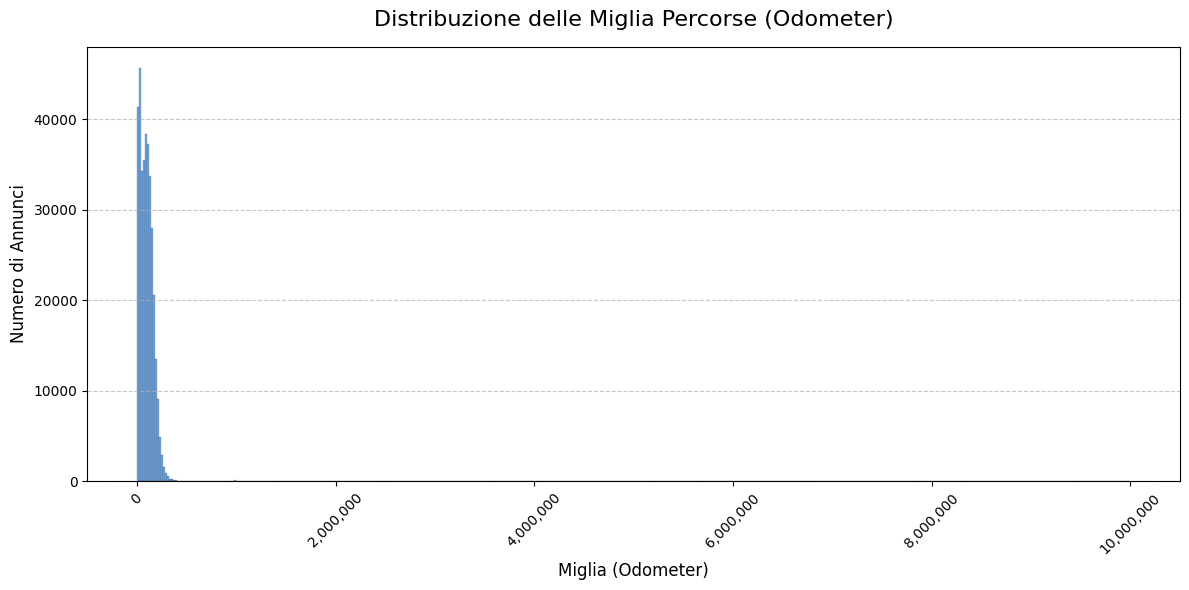

Grafico salvato con successo in: grafici/distribuzione_odometer.png


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker # Ci serve per formattare i numeri grandi

def crea_grafico_distribuzione_miglia(df: pd.DataFrame, output_path: str = "grafici/distribuzione_odometer.png"):
    """
    Genera e salva un istogramma che mostra la distribuzione 
    delle miglia percorse (odometer) dalle auto.
    """
    plt.figure(figsize=(12, 6))
    
    # Rimuoviamo eventuali valori nulli
    df_plot = df.dropna(subset=['odometer'])
    
    # Generiamo l'istogramma SENZA la linea KDE
    ax = sns.histplot(
        data=df_plot, 
        x="odometer", 
        bins=500,                # Creiamo 2500 "fasce" di chilometraggio
        color="#4A90E2"           # Il nostro blu flat
    )
    
    plt.title("Distribuzione delle Miglia Percorse (Odometer)", fontsize=16, pad=15)
    plt.xlabel("Miglia (Odometer)", fontsize=12)
    plt.ylabel("Numero di Annunci", fontsize=12)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # =====================================================================
    # NOVITÀ PER I NUMERI GRANDI
    # =====================================================================
    # 1. Mettiamo il separatore delle migliaia (es. 150,000 invece di 150000)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
    plt.xticks(rotation=45)
    
    # 2. Limitiamo il grafico a un massimo di 350.000 miglia. 
    # Oltre questa soglia di solito ci sono solo errori di inserimento dati (outliers)
    #plt.xlim(0, 350000)
    
    plt.tight_layout()
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Grafico salvato con successo in: {output_path}")
# =========================================================================
# ESEMPIO DI UTILIZZO
# =========================================================================
crea_grafico_distribuzione_miglia(df)

In [38]:
# =========================================================================
# TAGLIO DEGLI OUTLIER SUL CHILOMETRAGGIO (> 350.000 miglia)
# =========================================================================
totale_prima_odometer = df.shape[0]

# Manteniamo solo le auto con un chilometraggio sensato (fino a 350.000)
# Questo rimuove anche i probabili errori di battitura (es. 9999999)
df = df[df['odometer'] <= 350000].reset_index(drop=True)

totale_dopo_odometer = df.shape[0]
auto_rimosse_odometer = totale_prima_odometer - totale_dopo_odometer

print("=========================================================================")
print(f"Numero di auto prima del taglio miglia: {totale_prima_odometer}")
print(f"Auto con oltre 350.000 miglia rimosse: {auto_rimosse_odometer}")
print("-------------------------------------------------------------------------")
print("TAGLIO OUTLIER ODOMETER COMPLETATO!")
print(f"-> Numero di auto finali rimaste nel DataFrame: {totale_dopo_odometer}")
print("=========================================================================\n")

Numero di auto prima del taglio miglia: 351045
Auto con oltre 350.000 miglia rimosse: 2831
-------------------------------------------------------------------------
TAGLIO OUTLIER ODOMETER COMPLETATO!
-> Numero di auto finali rimaste nel DataFrame: 348214



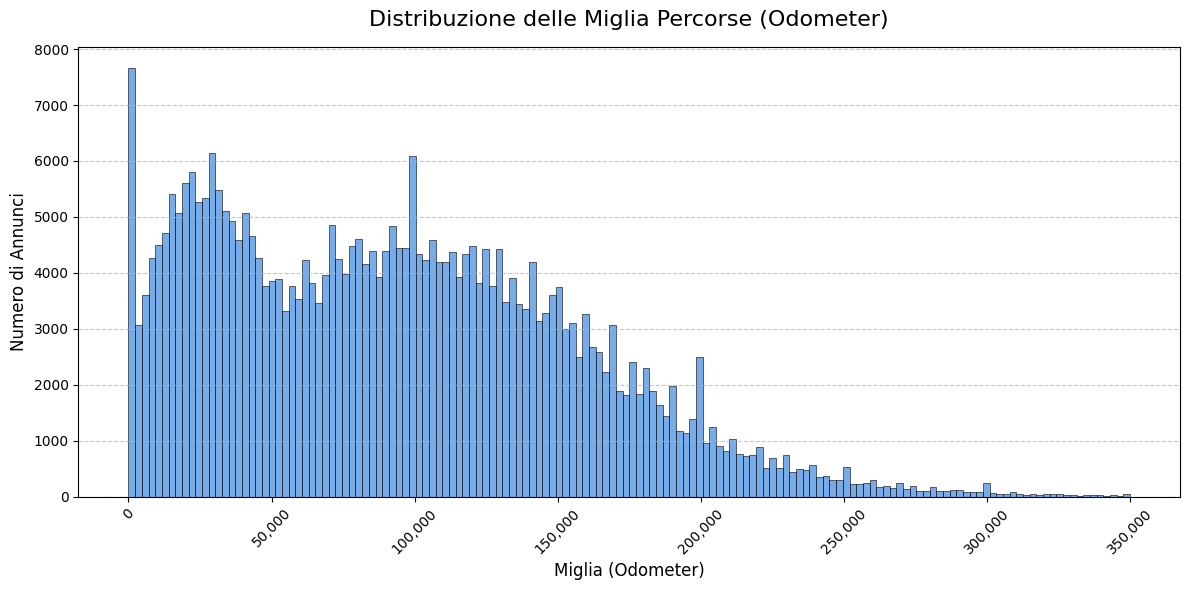

Grafico salvato con successo in: grafici/distribuzione_odometer_pulito.png


In [155]:
# Richiamiamo la funzione che hai già definito in precedenza, 
# passando il nuovo DataFrame pulito e aggiornando il nome del file
crea_grafico_distribuzione_miglia(df, output_path="grafici/distribuzione_odometer_pulito.png")

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def crea_dashboard_categoriche(df: pd.DataFrame, output_path: str = "grafici/dashboard_categoriche.png"):
    """
    Genera un'immagine singola contenente 4 grafici a barre per le 
    variabili categoriche: cylinders, fuel, title_status, transmission.
    """
    # Creiamo una figura grande e una griglia 2x2 di assi (axes)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Definiamo le colonne da plottare e i relativi titoli per i grafici
    colonne = ['cylinders', 'fuel', 'title_status', 'transmission']
    titoli = ['Numero di Cilindri', 'Alimentazione (Fuel)', 'Stato del Titolo (Title Status)', 'Trasmissione']
    
    # Appiattiamo la griglia 2x2 in una lista di 4 assi per poterci fare un ciclo 'for' sopra
    axes = axes.flatten()
    
    for i, col in enumerate(colonne):
        ax = axes[i]
        
        # 1. Pulizia: rimuoviamo i nulli per questa specifica colonna
        df_plot = df.dropna(subset=[col])
        
        # 2. Calcoliamo i conteggi ordinati
        conteggi = df_plot[col].value_counts().reset_index()
        conteggi.columns = [col, 'count']
        
        # 3. Creiamo il grafico a barre sul subplot specifico (ax=ax)
        sns.barplot(
            data=conteggi,
            x=col,
            y='count',
            color="#4A90E2", # Il blu moderno
            ax=ax
        )
        
        # 4. Aggiungiamo i numeri sopra le barre
        for container in ax.containers:
            ax.bar_label(
                container, 
                fmt='%d', 
                padding=4, 
                fontsize=10, 
                color="#333333"
            )
            
        # 5. Alziamo il limite Y del 15% per non far tagliare i numeri dal bordo superiore
        massimo = conteggi['count'].max()
        ax.set_ylim(0, massimo * 1.15)
        
        # 6. Personalizzazione testi e griglia del singolo grafico
        ax.set_title(titoli[i], fontsize=18, pad=10)
        ax.set_xlabel("") # Togliamo l'etichetta dell'asse X perché è già chiara dal titolo
        ax.set_ylabel("Conteggio", fontsize=11)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        # 7. Formattiamo le etichette sull'asse X (Capitalizzazione e Rotazione)
        # Convertiamo in stringa per evitare errori se 'cylinders' viene letto come numero in alcuni casi
        etichette = [str(label.get_text()).capitalize() for label in ax.get_xticklabels()]
        ax.set_xticklabels(etichette, rotation=45, ha='right', fontsize=16)

    # Ottimizziamo gli spazi tra i 4 grafici per non far accavallare scritte e titoli
    plt.tight_layout()
    
    # Salvataggio e visualizzazione
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Dashboard salvata con successo in: {output_path}")

/var/folders/vp/w9hfvh7j2dggvm8tlpf5831m0000gn/T/ipykernel_10444/3475074997.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etichette, rotation=45, ha='right', fontsize=16)
/var/folders/vp/w9hfvh7j2dggvm8tlpf5831m0000gn/T/ipykernel_10444/3475074997.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etichette, rotation=45, ha='right', fontsize=16)
/var/folders/vp/w9hfvh7j2dggvm8tlpf5831m0000gn/T/ipykernel_10444/3475074997.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etichette, rotation=45, ha='right', fontsize=16)
/var/folders/vp/w9hfvh7j2dggvm8tlpf5831m0000gn/T/ipykernel_10444/3475074997.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of t

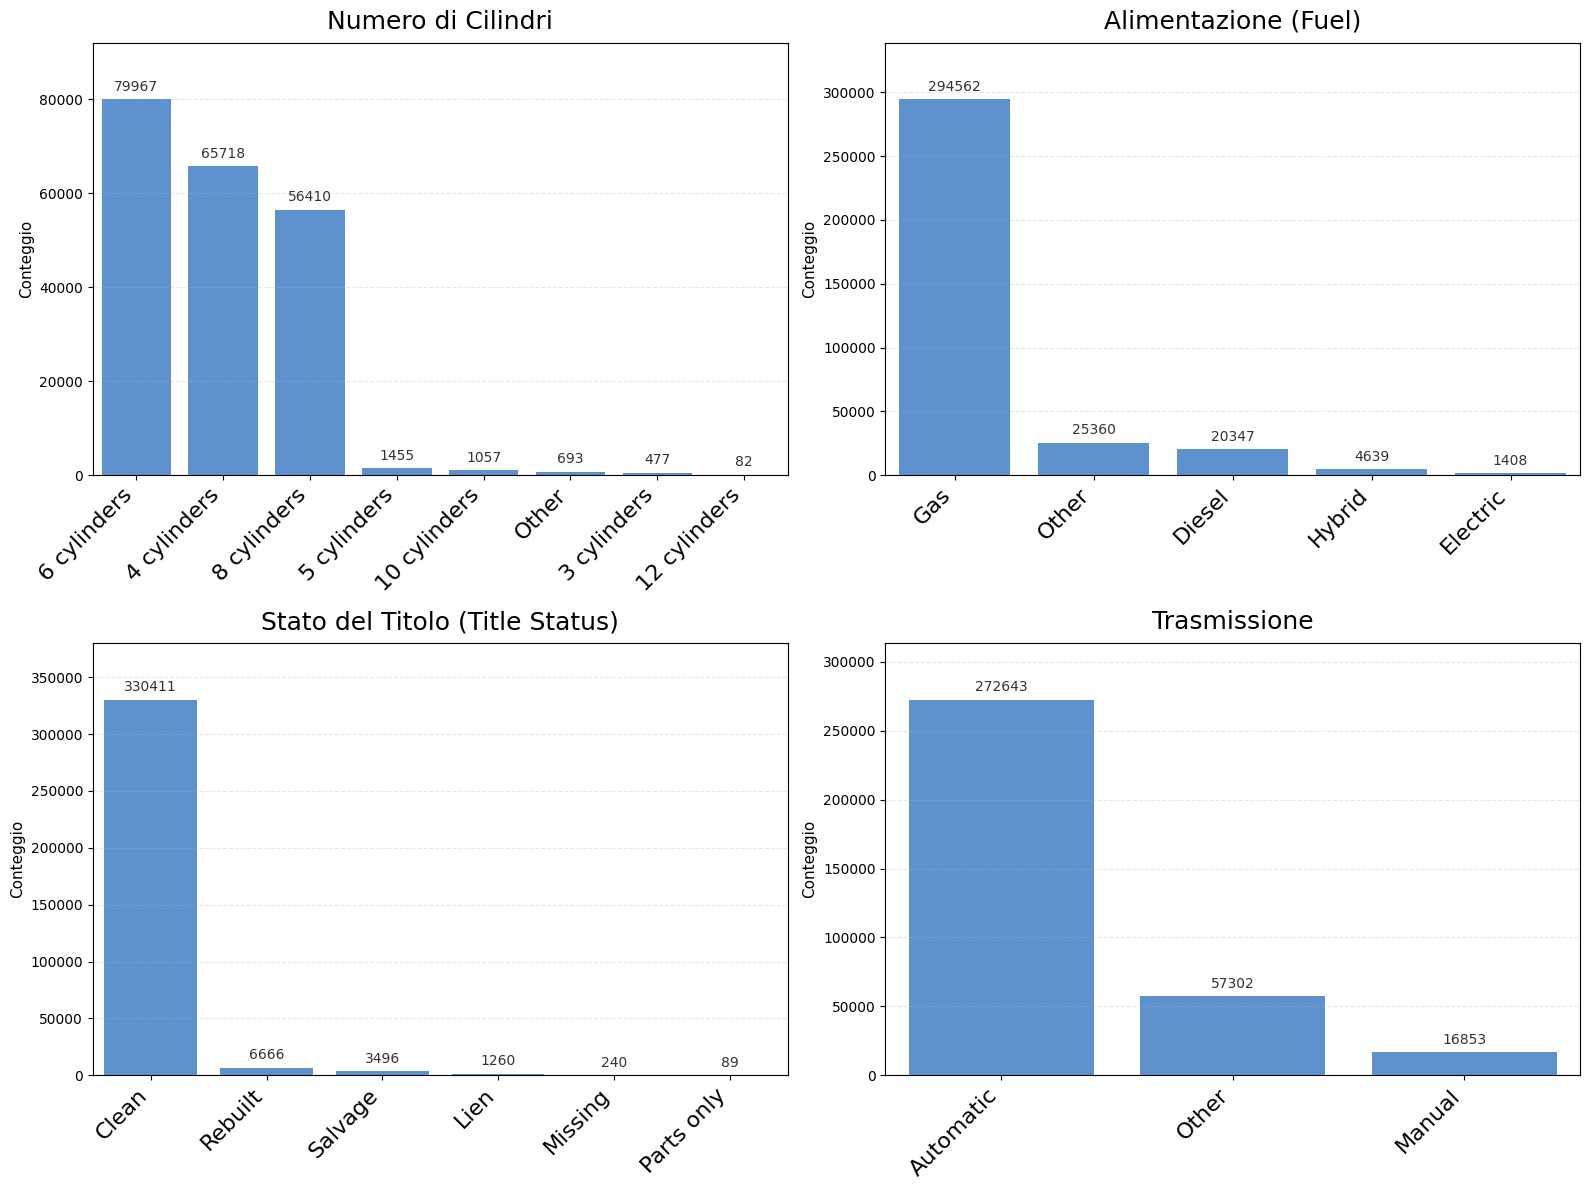

Dashboard salvata con successo in: grafici/dashboard_categoriche.png


In [42]:
crea_dashboard_categoriche(df)

In [59]:
def crea_matrice_correlazione_semi_specchio(df: pd.DataFrame, output_path: str = "grafici/matrice_correlazione_semi.png"):
    """
    Genera una heatmap di correlazione quadrata e perfettamente chiusa da bordi neri.
    """
    # 1. Selezioniamo solo le colonne numeriche
    df_numerico = df.select_dtypes(include=['int64', 'float64'])
    
    if df_numerico.shape[1] < 2:
        print("Scarsità di variabili numeriche per calcolare una matrice di correlazione.")
        return

    # 2. Calcoliamo la matrice di correlazione
    correlazione = df_numerico.corr()
    
    # 3. Matrice di stringhe per le annotazioni (vuota sopra la diagonale principale)
    annot_matrix = correlazione.astype(float).map("{:.2f}".format).to_numpy()
    sopra_diagonale = np.triu_indices_from(correlazione, k=1)
    annot_matrix[sopra_diagonale] = ""
    
    # 4. Maschera per non colorare la parte superiore (lasciarla bianca)
    maschera_colore = np.triu(np.ones_like(correlazione, dtype=bool), k=1)
    
    # 5. Prepariamo la figura (6x5)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_facecolor('white')
    
    # 6. Generiamo la Heatmap
    sns.heatmap(
        correlazione, 
        mask=maschera_colore,  
        annot=annot_matrix,    
        fmt="",                
        cmap="coolwarm",      
        vmin=-1,              
        vmax=1,               
        center=0,             
        square=True,          
        linewidths=0.5,        # Linee interne sottili
        linecolor='black',    
        cbar=False,           
        annot_kws={"size": 13, "weight": "bold"}, 
        ax=ax
    )
    
    # 7. [NOVITÀ] FORZIAMO I BORDI ESTERNI (SPINES) A CHIUDERE LA MATRICE
    # Questo aggiunge le linee nere mancanti sui lati esterni (sinistra, destra, sopra, sotto)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5) # Stesso spessore delle linee interne per omogeneità
    
    # 8. Spostamento dell'asse X in ALTO
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top') 

    # Ingrandiamo i nomi delle variabili sugli assi
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Rotazione dei label
    plt.xticks(rotation=30, ha='left')
    plt.yticks(rotation=0)
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Ottimizzazione dei margini
    plt.tight_layout()
    
    # 9. Salvataggio dell'immagine
    dir_name = os.path.dirname(output_path)
    if dir_name:
        os.makedirs(dir_name, exist_ok=True)
        
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Matrice perfetta salvata con successo in: {output_path}")

Matrice perfetta salvata con successo in: grafici/matrice_correlazione_semi.png


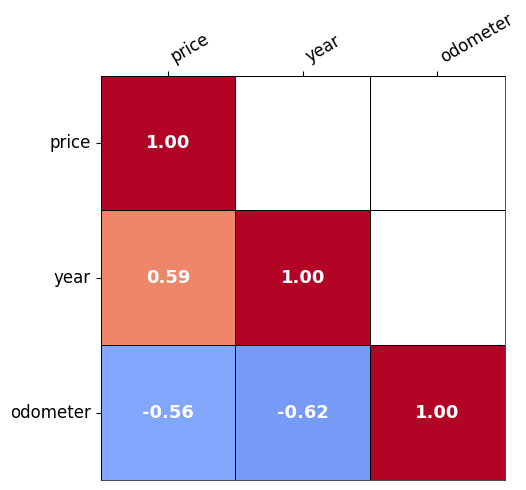

In [60]:
crea_matrice_correlazione_semi_specchio(df)

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def crea_matrice_correlazione_per_marca(df: pd.DataFrame, marca: str, output_dir: str = "grafici/correlazioni_marche"):
    """
    Filtra il DataFrame per una specifica marca, calcola la matrice di correlazione
    delle variabili numeriche e salva il grafico in una cartella dedicata, 
    utilizzando lo stile "semi-specchio" minimalista.
    """
    # 1. Filtriamo il dataset per la marca richiesta
    df_marca = df[df['manufacturer'].str.lower() == marca.lower()]
    
    # 2. Controllo di sicurezza: se ci sono troppo poche auto, interrompiamo
    if df_marca.shape[0] < 10:
        print(f"Salta '{marca}': Dati insufficienti ({df_marca.shape[0]} auto).")
        return
        
    # 3. Selezioniamo SOLO le colonne numeriche
    df_numerico = df_marca.select_dtypes(include=['int64', 'float64'])
    
    if df_numerico.shape[1] < 2:
        print(f"Salta '{marca}': Variabili numeriche insufficienti.")
        return
        
    # Calcoliamo la correlazione
    correlazione = df_numerico.corr()
    
    # --- APPLICAZIONE DELLO STILE "SEMI-SPECCHIO" ---
    
    # Matrice di stringhe per le annotazioni (vuota sopra la diagonale principale)
    annot_matrix = correlazione.astype(float).map("{:.2f}".format).to_numpy()
    sopra_diagonale = np.triu_indices_from(correlazione, k=1)
    annot_matrix[sopra_diagonale] = ""
    
    # Maschera per non colorare la parte superiore (lasciarla bianca)
    maschera_colore = np.triu(np.ones_like(correlazione, dtype=bool), k=1)
    
    # 4. Prepariamo la figura (6x5 mantiene le proporzioni ottimali per un numero ridotto di variabili)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_facecolor('white') # Sfondo bianco garantito per la parte superiore
    
    # 5. Generiamo la Heatmap
    sns.heatmap(
        correlazione, 
        mask=maschera_colore,  
        annot=annot_matrix,    
        fmt="",                
        cmap="coolwarm",      
        vmin=-1,              
        vmax=1,               
        center=0,             
        square=True,          
        linewidths=0.5,       # Linee interne sottili
        linecolor='black',    # Colore delle linee
        cbar=False,           # Niente barra dei colori laterale
        annot_kws={"size": 13, "weight": "bold"}, 
        ax=ax
    )
    
    # 6. CHIUSURA DEI BORDI (Spines)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)
    
    # 7. SPOSTAMENTO DELL'ASSE X IN ALTO E PERSONALIZZAZIONI
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top') 

    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Rotazione dei label (l'ha='left' funziona bene in alto)
    plt.xticks(rotation=30, ha='left')
    plt.yticks(rotation=0)
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Se desideri reinserire il titolo in futuro, rimuovi il '#' dalla riga sottostante
    # plt.title(f"Correlazione - {marca.capitalize()}", fontsize=14, fontweight='bold', pad=25)
    
    plt.tight_layout()
    
    # 8. SALVATAGGIO DEL FILE
    os.makedirs(output_dir, exist_ok=True)
    nome_file_pulito = marca.replace(' ', '_').lower()
    output_path = os.path.join(output_dir, f"corr_{nome_file_pulito}.png")
    
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    
    # IMPORTANTE: Chiudiamo la figura per liberare memoria RAM ad ogni ciclo
    plt.close()
    
    print(f"Salvata matrice per {marca.capitalize()} in: {output_path}")


# =========================================================================
# ESEMPIO DI UTILIZZO: CICLO SUI TOP 5 BRAND PIÙ DIFFUSI
# =========================================================================
print("Inizio generazione matrici di correlazione per marca...\n")

# Troviamo le 5 marche con più annunci nel DataFrame
# Assicurati che la variabile 'df' sia definita nel tuo ambiente prima di eseguire questa parte
top_5_marche = df['manufacturer'].value_counts().head(5).index.tolist()

# Facciamo girare la funzione per ognuna di queste marche
for marca_target in top_5_marche:
    crea_matrice_correlazione_per_marca(df, marca=marca_target)

print("\nOperazione completata! Controlla la cartella 'grafici/correlazioni_marche'")

Inizio generazione matrici di correlazione per marca...

Salvata matrice per Ford in: grafici/correlazioni_marche/corr_ford.png
Salvata matrice per Chevrolet in: grafici/correlazioni_marche/corr_chevrolet.png
Salvata matrice per Toyota in: grafici/correlazioni_marche/corr_toyota.png
Salvata matrice per Honda in: grafici/correlazioni_marche/corr_honda.png
Salvata matrice per Jeep in: grafici/correlazioni_marche/corr_jeep.png

Operazione completata! Controlla la cartella 'grafici/correlazioni_marche'


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def crea_matrice_correlazione_per_modello(df: pd.DataFrame, modello: str, output_dir: str = "grafici/correlazioni_modelli"):
    """
    Filtra il DataFrame per uno specifico modello di auto, calcola la matrice di correlazione
    delle variabili numeriche e salva il grafico in una nuova cartella dedicata.
    """
    # 1. Filtriamo il dataset per il modello richiesto
    # Convertiamo in stringa per sicurezza, nel caso ci siano modelli puramente numerici (es. '500')
    df_modello = df[df['model'].astype(str).str.lower() == str(modello).lower()]
    
    # 2. Controllo statistico di base
    if df_modello.shape[0] < 10:
        print(f"Salta '{modello}': Dati insufficienti ({df_modello.shape[0]} auto).")
        return
        
    # 3. Selezioniamo SOLO le colonne numeriche
    df_numerico = df_modello.select_dtypes(include=['int64', 'float64'])
    correlazione = df_numerico.corr()
    
    # 4. Generiamo la Heatmap
    plt.figure(figsize=(8, 8))
    maschera = np.triu(np.ones_like(correlazione, dtype=bool))
    
    sns.heatmap(
        correlazione, 
        mask=maschera,        
        annot=True,           
        fmt=".2f",            
        cmap="coolwarm",      
        vmin=-1,              
        vmax=1,               
        center=0,             
        square=True,          
        linewidths=0.5,       
        cbar_kws={"shrink": .8} 
    )
    
    # Titolo formattato (es. "f-150" diventa "F-150")
    plt.title(f"Correlazione Variabili - Modello: {str(modello).title()}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("")
    plt.ylabel("")
    
    plt.tight_layout()
    
    # 5. Creiamo la nuova cartella
    os.makedirs(output_dir, exist_ok=True)
    
    # Puliamo il nome del file sostituendo spazi e slash, molto comuni nei nomi dei modelli d'auto
    nome_file_pulito = str(modello).replace(' ', '_').replace('/', '-').lower()
    output_path = os.path.join(output_dir, f"corr_{nome_file_pulito}.png")
    
    # 6. Salvataggio in background e pulizia RAM
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()
    
    print(f"Salvata matrice per il modello '{str(modello).title()}' in: {output_path}")


# =========================================================================
# ESECUZIONE SUI 5 MODELLI PIÙ DIFFUSI
# =========================================================================
print("Inizio generazione matrici di correlazione per i top 5 modelli...\n")

# Troviamo dinamicamente i 5 modelli con il maggior numero di annunci
top_5_modelli = df['model'].value_counts().head(5).index.tolist()

for modello_target in top_5_modelli:
    crea_matrice_correlazione_per_modello(df, modello=modello_target)

print("\nOperazione completata! Controlla la cartella 'grafici/correlazioni_modelli'")

Inizio generazione matrici di correlazione per i top 5 modelli...

Salvata matrice per il modello 'F-150' in: grafici/correlazioni_modelli/corr_f-150.png
Salvata matrice per il modello 'Silverado 1500' in: grafici/correlazioni_modelli/corr_silverado_1500.png
Salvata matrice per il modello '1500' in: grafici/correlazioni_modelli/corr_1500.png
Salvata matrice per il modello 'Camry' in: grafici/correlazioni_modelli/corr_camry.png
Salvata matrice per il modello 'Accord' in: grafici/correlazioni_modelli/corr_accord.png

Operazione completata! Controlla la cartella 'grafici/correlazioni_modelli'


In [58]:
def crea_matrice_correlazione_per_modello(df: pd.DataFrame, modello: str, output_dir: str = "grafici/correlazioni_modelli"):
    """
    Filtra il DataFrame per uno specifico modello, calcola la matrice di correlazione
    e la salva utilizzando lo stile minimalista "semi-specchio" con bordi chiusi.
    """
    # 1. Filtriamo il dataset per il modello richiesto
    df_modello = df[df['model'].astype(str).str.lower() == str(modello).lower()]
    
    # 2. Salviamo il numero esatto di auto trovate per questo modello
    num_auto = df_modello.shape[0]
    
    # Controllo statistico
    if num_auto < 10:
        print(f"Salta '{modello}': Dati insufficienti ({num_auto} auto).")
        return
        
    # 3. Recuperiamo la marca associata a questo modello
    try:
        marca_associata = df_modello['manufacturer'].mode()[0].capitalize()
    except IndexError:
        marca_associata = "Sconosciuta" # Fallback di sicurezza
        
    # 4. Selezioniamo SOLO le colonne numeriche
    df_numerico = df_modello.select_dtypes(include=['int64', 'float64'])
    
    if df_numerico.shape[1] < 2:
        print(f"Salta '{modello}': Variabili numeriche insufficienti.")
        return
        
    correlazione = df_numerico.corr()
    
    # --- APPLICAZIONE DELLO STILE "SEMI-SPECCHIO" ---
    
    # Matrice di stringhe per le annotazioni (vuota sopra la diagonale principale)
    annot_matrix = correlazione.astype(float).map("{:.2f}".format).to_numpy()
    sopra_diagonale = np.triu_indices_from(correlazione, k=1)
    annot_matrix[sopra_diagonale] = ""
    
    # Maschera per non colorare la parte superiore (lasciarla bianca)
    maschera_colore = np.triu(np.ones_like(correlazione, dtype=bool), k=1)
    
    # 5. Prepariamo la figura compatta
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_facecolor('white') # Sfondo bianco per la parte superiore
    
    # 6. Generiamo la Heatmap
    sns.heatmap(
        correlazione, 
        mask=maschera_colore,  
        annot=annot_matrix,    
        fmt="",                
        cmap="coolwarm",      
        vmin=-1,              
        vmax=1,               
        center=0,             
        square=True,          
        linewidths=0.5,       # Linee interne sottili
        linecolor='black',    # Colore delle linee
        cbar=False,           # Niente barra laterale
        annot_kws={"size": 13, "weight": "bold"}, 
        ax=ax
    )
    
    # 7. CHIUSURA DEI BORDI (Spines)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)
    
    # 8. SPOSTAMENTO DELL'ASSE X IN ALTO E PERSONALIZZAZIONI
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top') 

    ax.tick_params(axis='both', which='major', labelsize=12)
    
    plt.xticks(rotation=30, ha='left')
    plt.yticks(rotation=0)
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # (Opzionale) Titolo commentato per rispettare lo stile senza titolo
    # titolo_grafico = f"{marca_associata} {str(modello).title()} ({num_auto} annunci)"
    # ax.set_title(titolo_grafico, fontsize=14, pad=25)
    
    plt.tight_layout()
    
    # 9. Creiamo la nuova cartella
    os.makedirs(output_dir, exist_ok=True)
    
    nome_file_pulito = str(modello).replace(' ', '_').replace('/', '-').lower()
    output_path = os.path.join(output_dir, f"corr_{nome_file_pulito}.png")
    
    # 10. Salvataggio in background e pulizia RAM
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()
    
    print(f"Salvata matrice per {marca_associata} {str(modello).title()} ({num_auto} auto) in: {output_path}")


# =========================================================================
# ESECUZIONE SUI 10 MODELLI PIÙ DIFFUSI
# =========================================================================
print("Inizio generazione matrici di correlazione per i top 10 modelli...\n")

# Assicurati che la variabile 'df' sia definita nel tuo ambiente
top_10_modelli = df['model'].value_counts().head(10).index.tolist()

for modello_target in top_10_modelli:
    crea_matrice_correlazione_per_modello(df, modello=modello_target)

print("\nOperazione completata! Controlla la cartella 'grafici/correlazioni_modelli'")

Inizio generazione matrici di correlazione per i top 10 modelli...

Salvata matrice per Ford F-150 (6769 auto) in: grafici/correlazioni_modelli/corr_f-150.png
Salvata matrice per Chevrolet Silverado 1500 (4324 auto) in: grafici/correlazioni_modelli/corr_silverado_1500.png
Salvata matrice per Ram 1500 (3665 auto) in: grafici/correlazioni_modelli/corr_1500.png
Salvata matrice per Toyota Camry (2717 auto) in: grafici/correlazioni_modelli/corr_camry.png
Salvata matrice per Honda Accord (2600 auto) in: grafici/correlazioni_modelli/corr_accord.png
Salvata matrice per Chevrolet Silverado (2589 auto) in: grafici/correlazioni_modelli/corr_silverado.png
Salvata matrice per Honda Civic (2498 auto) in: grafici/correlazioni_modelli/corr_civic.png
Salvata matrice per Ford Escape (2445 auto) in: grafici/correlazioni_modelli/corr_escape.png
Salvata matrice per Jeep Wrangler (2433 auto) in: grafici/correlazioni_modelli/corr_wrangler.png
Salvata matrice per Nissan Altima (2378 auto) in: grafici/correlaz

In [166]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_wo_train, X_wo_test, y_wo_train, y_wo_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X["manufacturer"])

# --- 1. RIMOZIONE VALORI NULLI ---
colonne_da_droppare = ['fuel', 'year', 'model', 'transmission', 'title_status', 'odometer', 'manufacturer']

X_wo_train = X_wo_train.dropna(subset=colonne_da_droppare)
y_wo_train = y_wo_train.loc[X_wo_train.index] # Allineiamo le etichette (y) agli indici rimasti in X

X_wo_test = X_wo_test.dropna(subset=colonne_da_droppare)
y_wo_test = y_wo_test.loc[X_wo_test.index]

# --- 2. RIEMPIMENTO VALORI NULLI CON 'Unknown' (Corretto) ---
# Attenzione: lo facciamo su X_train e X_test, non su df!
colonne_da_riempire = ['condition', 'cylinders', 'drive', 'size', 'type', 'paint_color']

X_wo_train[colonne_da_riempire] = X_wo_train[colonne_da_riempire].fillna('Unknown')
X_wo_test[colonne_da_riempire] = X_wo_test[colonne_da_riempire].fillna('Unknown')

print(f"Dimensioni finali X_wo_train: {X_wo_train.shape}")
print(f"Dimensioni finali X_wo_test: {X_wo_test.shape}")

# --- 3. SALVATAGGIO IN CSV ---
print("Salvataggio dei file CSV in corso...")

# index=False evita di salvare la numerazione delle righe come colonna aggiuntiva nel CSV
X_wo_train.to_csv('X_wo_train.csv', index=False)
X_wo_test.to_csv('X_wo_test.csv', index=False)

# y_train e y_test sono Series, ma il metodo to_csv funziona allo stesso modo
y_wo_train.to_csv('y_wo_train.csv', index=False)
y_wo_test.to_csv('y_wo_test.csv', index=False)

print("Tutti e 4 i dataset sono stati salvati con successo!")

Dimensioni finali X_wo_train: (268959, 14)
Dimensioni finali X_wo_test: (67250, 14)
Salvataggio dei file CSV in corso...
Tutti e 4 i dataset sono stati salvati con successo!


In [167]:
X_wo_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268959 entries, 234599 to 236637
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          268959 non-null  float64
 1   manufacturer  268959 non-null  object 
 2   model         268959 non-null  object 
 3   condition     268959 non-null  object 
 4   cylinders     268959 non-null  object 
 5   fuel          268959 non-null  object 
 6   odometer      268959 non-null  float64
 7   title_status  268959 non-null  object 
 8   transmission  268959 non-null  object 
 9   drive         268959 non-null  object 
 10  size          268959 non-null  object 
 11  type          268959 non-null  object 
 12  paint_color   268959 non-null  object 
 13  state         268959 non-null  object 
dtypes: float64(2), object(12)
memory usage: 30.8+ MB


In [168]:
import pandas as pd
X_wo_train = pd.read_csv('X_wo_train.csv')
X_wo_train['manufacturer'].unique()

array(['dodge', 'toyota', 'ford', 'honda', 'jeep', 'gmc', 'volkswagen',
       'chevrolet', 'infiniti', 'mercedes-benz', 'kia', 'ram', 'nissan',
       'bmw', 'audi', 'chrysler', 'hyundai', 'mazda', 'buick', 'lincoln',
       'jaguar', 'lexus', 'mini', 'volvo', 'acura', 'cadillac', 'rover',
       'mitsubishi', 'subaru', 'fiat', 'porsche', 'tesla', 'alfa-romeo',
       'harley-davidson'], dtype=object)